Name :- Patel Viraj

PRN No :- 31

Name :- Vikramaditya Singh

PRN No :- 51

------------------------------------------------------------------

In [25]:
import pandas as pd
import numpy as np

In [26]:
df = pd.read_csv('regional_sales_data.txt.', sep = ' ')
df.head()

,Region_ID,Units_Sold,Unit_Price,Store_name,Country
0,REG_01,NaN,34.75,Beta_Retail,UK
1,REG_01,149.0,17.82,Delta_Shop,India
2,REG_01,NaN,30.94,Epsilon_Hub,India
3,REG_02,149.0,47.75,Delta_Shop,Canada
4,REG_03,11.0,78.29,Beta_Retail,Germany


------ Q1 -----

Check and replace all missing values in the Units_Sold column with the median value of that specific column


In [27]:
df.isnull().sum()

Region_ID     0
Units_Sold    5
Unit_Price    0
Store_name    0
Country       0
dtype: int64

In [28]:
# Filled Specific Column With It's Mean
df['Units_Sold'] = df['Units_Sold'].fillna(np.mean(df['Units_Sold']).round())
df.head()

,Region_ID,Units_Sold,Unit_Price,Store_name,Country
0,REG_01,88.0,34.75,Beta_Retail,UK
1,REG_01,149.0,17.82,Delta_Shop,India
2,REG_01,88.0,30.94,Epsilon_Hub,India
3,REG_02,149.0,47.75,Delta_Shop,Canada
4,REG_03,11.0,78.29,Beta_Retail,Germany


------- Q2 -------

Calculate the total units sold and the average unit price for each Store_name.
Identify which store has generated the highest total units sold 

In [29]:
df['Units_Sold'].dtype

dtype('float64')

In [30]:
df.groupby('Store_name').agg(Total_Unit_Sales  = ('Units_Sold','sum'), Average_Unit_Price = ('Unit_Price','mean')).reset_index().round(2)

,Store_name,Total_Unit_Sales,Average_Unit_Price
0,Alpha_Mart,857.0,62.29
1,Beta_Retail,1030.0,59.82
2,Delta_Shop,1001.0,40.49
3,Epsilon_Hub,1364.0,59.32
4,Gamma_Store,1045.0,55.27


------ Q3 ------

Create a new column named Total_Revenue, calculated by multiplying Units_Sold by Unit_Price

In [31]:
df['Total_Revenue'] = df['Units_Sold'] * df['Unit_Price']
df.head()

,Region_ID,Units_Sold,Unit_Price,Store_name,Country,Total_Revenue
0,REG_01,88.0,34.75,Beta_Retail,UK,3058.00
1,REG_01,149.0,17.82,Delta_Shop,India,2655.18
2,REG_01,88.0,30.94,Epsilon_Hub,India,2722.72
3,REG_02,149.0,47.75,Delta_Shop,Canada,7114.75
4,REG_03,11.0,78.29,Beta_Retail,Germany,861.19


------ Q4 ------

Group the data by Region_ID and calculate the sum of Total_Revenue for each region

In [32]:
rev_df = df.groupby('Region_ID')['Total_Revenue'].agg(Total_Revenue = sum).reset_index()
rev_df

,Region_ID,Total_Revenue
0,REG_01,114444.96
1,REG_02,62891.10
2,REG_03,62422.10
3,REG_04,52051.47


------- Q5 -------

Use Matplotlib to plot a bar chart showing Region_ID on the x-axis and the sum of Total_Revenue on the y-axis. 
Set the bar colour to green, add a grid on the y-axis, and give the chart a clear title

In [33]:
import matplotlib.pyplot as plt

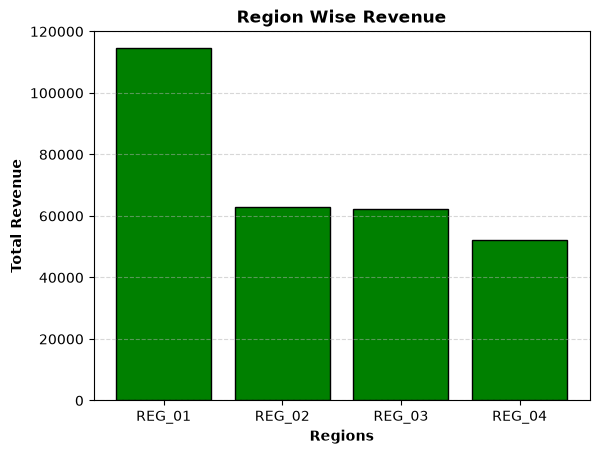

In [34]:
plt.bar(rev_df['Region_ID'],rev_df['Total_Revenue'], color = 'green', edgecolor = 'black')
plt.grid(axis = 'y', ls = '--', alpha = 0.5)
plt.title('Region Wise Revenue', fontweight="bold")
plt.xlabel('Regions', fontweight="bold")
plt.ylabel('Total Revenue', fontweight="bold")
plt.show()

Interpretation -> Each Green Bar in Figure Show The Total Revenue of Particular Region. We have Plot The Regions On x-axis and Total Reveue
For That Region On y-axis , It Helps us to Immediately Spot Our Highest and Lowest Performing Region.

------- Q6 -------

Create a scatter plot using Seaborn mapping Unit_Price on the x-axis against Units_Sold on the y-axis

In [35]:
import seaborn as sns

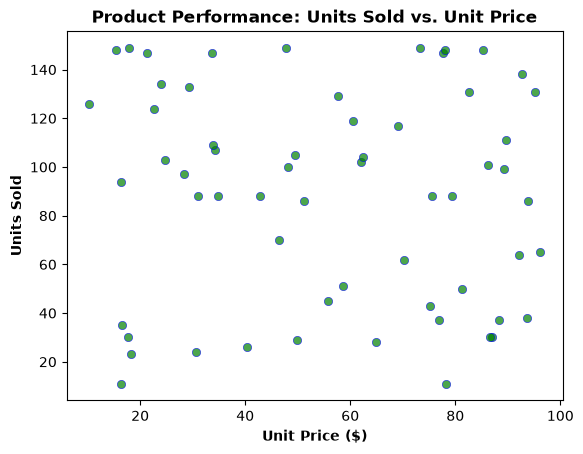

In [36]:
sns.scatterplot(df, x = 'Unit_Price', y = 'Units_Sold', color = 'green', alpha= 0.7, edgecolor='b')
plt.title("Product Performance: Units Sold vs. Unit Price", fontweight="bold")
plt.xlabel("Unit Price ($)",fontweight="bold")
plt.ylabel("Units Sold",fontweight="bold")
plt.show()

Interpretation -> Above Figure Maps The Behaviour Of Product Unit With It's Price , It Tell Us How The Unit Sell are Behave in Different Price , Scatter Plot Shows The Relationship or Correlation Between Product Unit And It's Price.